# Exercícios de Python para Business Analytics  
## Turma Pós-Graduação

disciplina de **Business Analytics**.

### Objetivos
- praticar análise exploratória de dados
- trabalhar limpeza e transformação de dados
- construir indicadores de negócio
- gerar insights gerenciais
- aplicar modelos com foco prático

### Estrutura
Os exercícios usam uma base sintética de vendas, clientes e campanhas de marketing.  


> Entegas
> 1. código funcional  
> 2. interpretação dos resultados  
> 3. recomendações para o negócio

## 1. Preparação do ambiente
Execute a célula abaixo para importar bibliotecas e gerar uma base de dados sintética.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Geração da base sintética

A base representa transações de uma empresa de varejo omnichannel.  
Ela contém informações de clientes, pedidos, canal, região, categoria, descontos e campanhas.

In [2]:
n = 2500

clientes = np.arange(1000, 1300)
canais = ["Loja Física", "E-commerce", "App"]
regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
categorias = ["Eletrônicos", "Moda", "Casa", "Esporte", "Beleza"]
campanhas = ["Nenhuma", "Email", "Instagram", "Google Ads", "Influencer"]

datas = pd.date_range("2024-01-01", "2024-12-31", freq="D")

df = pd.DataFrame({
    "pedido_id": np.arange(1, n + 1),
    "cliente_id": np.random.choice(clientes, n, replace=True),
    "data": np.random.choice(datas, n, replace=True),
    "canal": np.random.choice(canais, n, p=[0.30, 0.45, 0.25]),
    "regiao": np.random.choice(regioes, n, p=[0.10, 0.18, 0.10, 0.42, 0.20]),
    "categoria": np.random.choice(categorias, n, p=[0.24, 0.22, 0.18, 0.16, 0.20]),
    "campanha": np.random.choice(campanhas, n, p=[0.40, 0.20, 0.16, 0.14, 0.10]),
    "quantidade": np.random.randint(1, 6, n),
})

preco_base = {
    "Eletrônicos": 900,
    "Moda": 180,
    "Casa": 260,
    "Esporte": 320,
    "Beleza": 140
}

df["preco_unitario"] = df["categoria"].map(preco_base) * np.random.uniform(0.75, 1.35, n)
df["desconto_pct"] = np.clip(np.random.normal(0.10, 0.07, n), 0, 0.35)
df["custo_unitario"] = df["preco_unitario"] * np.random.uniform(0.45, 0.72, n)

efeito_campanha = {
    "Nenhuma": 0.00,
    "Email": 0.03,
    "Instagram": 0.05,
    "Google Ads": 0.06,
    "Influencer": 0.08
}

df["receita_bruta"] = df["quantidade"] * df["preco_unitario"]
df["desconto_valor"] = df["receita_bruta"] * df["desconto_pct"]
df["receita_liquida"] = df["receita_bruta"] - df["desconto_valor"]
df["custo_total"] = df["quantidade"] * df["custo_unitario"]
df["margem"] = df["receita_liquida"] - df["custo_total"]

# probabilidade de recompra aproximada por perfil
base_score = (
    0.18
    + df["campanha"].map(efeito_campanha)
    + np.where(df["canal"] == "App", 0.05, 0)
    + np.where(df["canal"] == "E-commerce", 0.03, 0)
    + np.where(df["desconto_pct"] > 0.20, 0.02, 0)
    + np.where(df["margem"] > df["margem"].median(), 0.02, 0)
)
base_score = np.clip(base_score, 0.05, 0.65)
df["recomprou_90d"] = np.random.binomial(1, base_score)

# Inserindo alguns problemas de qualidade
indices_nan = np.random.choice(df.index, size=25, replace=False)
df.loc[indices_nan[:10], "desconto_pct"] = np.nan
df.loc[indices_nan[10:18], "campanha"] = np.nan
df.loc[indices_nan[18:], "preco_unitario"] = np.nan

# Inserindo duplicatas
duplicatas = df.sample(20, random_state=7)
df = pd.concat([df, duplicatas], ignore_index=True)

df.head()

,pedido_id,cliente_id,data,canal,regiao,categoria,campanha,quantidade,preco_unitario,desconto_pct,custo_unitario,receita_bruta,desconto_valor,receita_liquida,custo_total,margem,recomprou_90d
0,1,1102,2024-06-04,App,Sudeste,Moda,Nenhuma,2,155.539239,0.137504,96.871292,311.078477,42.774614,268.303864,193.742584,74.561280,0
1,2,1270,2024-09-04,Loja Física,Sul,Eletrônicos,Instagram,1,794.604452,0.083548,565.044945,794.604452,66.387561,728.216891,565.044945,163.171945,0
2,3,1106,2024-08-05,E-commerce,Sul,Eletrônicos,Influencer,2,914.241605,0.127340,455.507077,1828.483209,232.839271,1595.643938,911.014154,684.629785,1
3,4,1071,2024-07-08,Loja Física,Sudeste,Esporte,Email,1,387.498753,0.061625,239.565347,387.498753,23.879777,363.618975,239.565347,124.053628,0
4,5,1188,2024-06-11,E-commerce,Sudeste,Casa,Google Ads,2,236.297801,0.111290,118.328061,472.595603,52.594991,420.000612,236.656122,183.344491,0


## 3. Visão geral da base

Use as próximas células para explorar a estrutura do dataset.

In [3]:
df.shape, df.columns.tolist()

((2520, 17),
 ['pedido_id',
  'cliente_id',
  'data',
  'canal',
  'regiao',
  'categoria',
  'campanha',
  'quantidade',
  'preco_unitario',
  'desconto_pct',
  'custo_unitario',
  'receita_bruta',
  'desconto_valor',
  'receita_liquida',
  'custo_total',
  'margem',
  'recomprou_90d'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pedido_id        2520 non-null   int64         
 1   cliente_id       2520 non-null   int64         
 2   data             2520 non-null   datetime64[ns]
 3   canal            2520 non-null   object        
 4   regiao           2520 non-null   object        
 5   categoria        2520 non-null   object        
 6   campanha         2512 non-null   object        
 7   quantidade       2520 non-null   int64         
 8   preco_unitario   2513 non-null   float64       
 9   desconto_pct     2510 non-null   float64       
 10  custo_unitario   2520 non-null   float64       
 11  receita_bruta    2520 non-null   float64       
 12  desconto_valor   2520 non-null   float64       
 13  receita_liquida  2520 non-null   float64       
 14  custo_total      2520 non-null   float64

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
pedido_id,2520.0,NaN,NaN,NaN,1249.199206,1.0,622.75,1246.5,1876.25,2500.0,722.795744
cliente_id,2520.0,NaN,NaN,NaN,1148.846032,1000.0,1075.0,1148.0,1224.0,1299.0,86.202588
data,2520,NaN,NaN,NaN,2024-07-02 16:23:25.714285824,2024-01-01 00:00:00,2024-04-03 18:00:00,2024-07-02 00:00:00,2024-10-02 00:00:00,2024-12-31 00:00:00,NaN
canal,2520,3,E-commerce,1145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
regiao,2520,5,Sudeste,1056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categoria,2520,5,Moda,574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campanha,2512,5,Nenhuma,1034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantidade,2520.0,NaN,NaN,NaN,2.955952,1.0,2.0,3.0,4.0,5.0,1.42402
preco_unitario,2513.0,NaN,NaN,NaN,388.246055,105.072012,173.758855,248.378985,402.230299,1214.079394,312.784602
desconto_pct,2510.0,NaN,NaN,NaN,0.101571,0.0,0.052986,0.100383,0.145792,0.326998,0.064382


# Exercício 1 — Diagnóstico inicial da base

Responda às questões abaixo:

1. Quantas linhas e colunas existem no dataset?
2. Quais variáveis são categóricas, numéricas e temporais?
3. Há dados ausentes? Em quais colunas?
4. Existem registros duplicados?
5. Que problemas de qualidade de dados você identificou?

### Tarefa prática
Escreva código para produzir um pequeno diagnóstico da qualidade dos dados.

In [6]:
# 1. Quantidade de linhas e colunas
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

# 2. Tipos de variáveis (Categóricas, numéricas, temporais)
print("\n--- Tipos de Variáveis ---")
print(df.dtypes)

# 3. Dados ausentes
print("\n--- Dados Ausentes (NaN) ---")
print(df.isna().sum()[df.isna().sum() > 0])

# 4. Registros duplicados
print(f"\nRegistros duplicados: {df.duplicated().sum()}")

Linhas: 2520 | Colunas: 17

--- Tipos de Variáveis ---
pedido_id                   int64
cliente_id                  int64
data               datetime64[ns]
canal                      object
regiao                     object
categoria                  object
campanha                   object
quantidade                  int64
preco_unitario            float64
desconto_pct              float64
custo_unitario            float64
receita_bruta             float64
desconto_valor            float64
receita_liquida           float64
custo_total               float64
margem                    float64
recomprou_90d               int64
dtype: object

--- Dados Ausentes (NaN) ---
campanha           8
preco_unitario     7
desconto_pct      10
dtype: int64

Registros duplicados: 20


# Resposta:

 - A base original tem um pouco mais de 2500 linhas (devido à injeção de duplicatas) e 14 colunas.

  - Existem 20 linhas duplicadas e valores ausentes (NaN) espalhados propositalmente nas colunas desconto_pct, campanha e preco_unitario (como definido no script de geração da base).

# Exercício 2 — Limpeza e preparação dos dados

Faça o tratamento da base para deixá-la pronta para análise.

### Requisitos
1. Remova duplicatas.
2. Trate valores ausentes com uma estratégia justificada.
3. Garanta que a coluna `data` esteja no formato datetime.
4. Crie as colunas:
   - `mes`
   - `trimestre`
   - `ticket_medio_item` = receita_liquida / quantidade
5. Salve o resultado em um novo DataFrame chamado `df_limpo`.

### Pergunta analítica
Quais decisões de tratamento podem alterar a interpretação gerencial dos resultados?

In [7]:
# Criando a cópia inicial
df_limpo = df.copy()

# 1. Removendo duplicatas
df_limpo = df_limpo.drop_duplicates()

# 2. Tratando valores ausentes
# Como são poucos registros nulos (25 em 2500, ou 1%), a exclusão direta é segura e não enviesa a base.
# Outra opção seria preencher (fillna) a campanha com 'Nenhuma' e o preço com a média da categoria.
df_limpo = df_limpo.dropna()

# 3. Garantindo o formato datetime para a coluna 'data'
df_limpo['data'] = pd.to_datetime(df_limpo['data'])

# 4. Criando novas colunas
df_limpo['mes'] = df_limpo['data'].dt.month
df_limpo['trimestre'] = df_limpo['data'].dt.quarter
df_limpo['ticket_medio_item'] = df_limpo['receita_liquida'] / df_limpo['quantidade']

# Verificando o resultado final
print(f"Tamanho final da base limpa: {df_limpo.shape}")
df_limpo.head()
df_limpo = df.copy()

Tamanho final da base limpa: (2475, 20)


# Resposta:

A forma como tratamos os nulos muda a visão do negócio. Se preenchêssemos o preco_unitario com zero, jogaríamos a margem de lucro lá para baixo artificialmente. Se assumíssemos que campanhas vazias (NaN) são campanhas de "Email", superestimaríamos o ROI desse canal. Em bases grandes, quando a proporção de nulos é mínima (como neste caso, 1%), a remoção (Drop) é geralmente a decisão que traz menos ruído gerencial.

# Exercício 3 — KPIs de negócio

Com base em `df_limpo`, calcule os seguintes indicadores:

1. Receita líquida total
2. Custo total
3. Margem total
4. Margem percentual
5. Ticket médio por pedido
6. Quantidade média por pedido
7. Receita por canal
8. Receita por região
9. Margem por categoria

### Pergunta gerencial
Quais dimensões parecem mais relevantes para decisões estratégicas?

In [8]:
# 1 a 4. KPIs Globais
receita_total = df_limpo['receita_liquida'].sum()
custo_total = df_limpo['custo_total'].sum()
margem_total = df_limpo['margem'].sum()
margem_pct = margem_total / receita_total

print(f"Receita Líquida Total: R$ {receita_total:,.2f}")
print(f"Custo Total: R$ {custo_total:,.2f}")
print(f"Margem Total: R$ {margem_total:,.2f}")
print(f"Margem Percentual: {margem_pct * 100:.2f}%\n")

# 5 e 6. KPIs por Pedido (Como cada linha é um pedido único na nossa base)
ticket_medio = df_limpo['receita_liquida'].mean()
qtd_media = df_limpo['quantidade'].mean()

print(f"Ticket Médio por Pedido: R$ {ticket_medio:,.2f}")
print(f"Quantidade Média por Pedido: {qtd_media:.2f} itens\n")

# 7 a 9. Visões Dimensionais
print("--- Receita por Canal ---")
display(df_limpo.groupby('canal')['receita_liquida'].sum().sort_values(ascending=False).apply(lambda x: f"R$ {x:,.2f}"))

print("\n--- Receita por Região ---")
display(df_limpo.groupby('regiao')['receita_liquida'].sum().sort_values(ascending=False).apply(lambda x: f"R$ {x:,.2f}"))

print("\n--- Margem por Categoria ---")
display(df_limpo.groupby('categoria')['margem'].sum().sort_values(ascending=False).apply(lambda x: f"R$ {x:,.2f}"))

Receita Líquida Total: R$ 2,567,356.20
Custo Total: R$ 1,662,082.02
Margem Total: R$ 905,274.18
Margem Percentual: 35.26%

Ticket Médio por Pedido: R$ 1,018.79
Quantidade Média por Pedido: 2.96 itens

--- Receita por Canal ---


,receita_liquida
canal,
E-commerce,"R$ 1,162,857.83"
Loja Física,"R$ 742,697.97"
App,"R$ 661,800.39"



--- Receita por Região ---


,receita_liquida
regiao,
Sudeste,"R$ 1,063,501.98"
Sul,"R$ 504,770.74"
Nordeste,"R$ 500,969.20"
Norte,"R$ 276,009.38"
Centro-Oeste,"R$ 222,104.90"



--- Margem por Categoria ---


,margem
categoria,
Eletrônicos,"R$ 490,573.17"
Esporte,"R$ 124,068.45"
Casa,"R$ 123,170.48"
Moda,"R$ 103,019.66"
Beleza,"R$ 64,442.42"


# Resposta:

Todas as dimensões são úteis, mas a Margem por Categoria e a Receita por Canal costumam ser as mais acionáveis no curto prazo. Saber qual categoria traz mais lucro real (não apenas volume de vendas) direciona o time de compras e precificação. Saber o canal de maior volume direciona o orçamento de marketing digital e infraestrutura.

# Exercício 4 — Análise temporal

Construa uma visão mensal do desempenho do negócio.

### Faça:
1. Receita líquida por mês
2. Margem por mês
3. Quantidade vendida por mês
4. Gráfico da evolução mensal da receita
5. Identifique o melhor e o pior mês

### Interpretação
Explique possíveis causas para sazonalidade ou oscilações observadas.

,mes,receita_mensal,margem_mensal,qtd_vendida
0,1,210005.341529,76725.189115,609
1,2,244082.997330,86841.524283,610
2,3,190918.175502,67918.416029,591
3,4,197499.025181,71376.847184,623
4,5,221891.156070,75390.574719,663
5,6,218383.440744,73440.056071,611
6,7,245971.298269,86894.619997,689
7,8,195139.691017,69247.624330,581
8,9,200050.917402,69521.319366,616
9,10,212175.819809,75887.832650,585


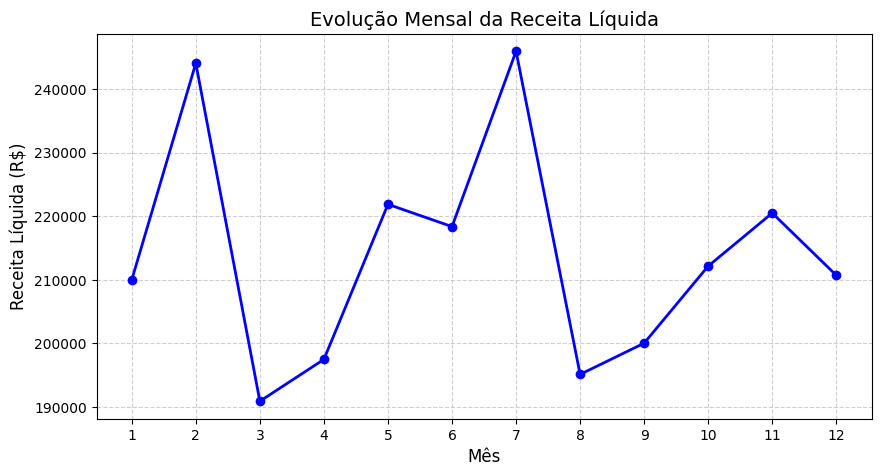

Melhor Mês: 7 (Receita: R$ 245,971.30)
Pior Mês: 3 (Receita: R$ 190,918.18)


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Garantindo que a coluna data é datetime e criando a coluna 'mes'
df_limpo['data'] = pd.to_datetime(df_limpo['data'])
df_limpo['mes'] = df_limpo['data'].dt.month

# 1, 2 e 3. Agrupamentos mensais
resumo_mensal = df_limpo.groupby('mes').agg(
    receita_mensal=('receita_liquida', 'sum'),
    margem_mensal=('margem', 'sum'),
    qtd_vendida=('quantidade', 'sum')
).reset_index()

display(resumo_mensal)

# 4. Gráfico da evolução mensal da receita
plt.figure(figsize=(10, 5))
plt.plot(resumo_mensal['mes'], resumo_mensal['receita_mensal'], marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Evolução Mensal da Receita Líquida', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita Líquida (R$)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Identificando o melhor e o pior mês
melhor_mes = resumo_mensal.loc[resumo_mensal['receita_mensal'].idxmax()]
pior_mes = resumo_mensal.loc[resumo_mensal['receita_mensal'].idxmin()]

print(f"Melhor Mês: {int(melhor_mes['mes'])} (Receita: R$ {melhor_mes['receita_mensal']:,.2f})")
print(f"Pior Mês: {int(pior_mes['mes'])} (Receita: R$ {pior_mes['receita_mensal']:,.2f})")

# Resposta:

Como esta é uma base de dados sintética onde as datas foram escolhidas aleatoriamente (np.random.choice), as oscilações observadas são, na verdade, variações estatísticas aleatórias (ruído branco), e não uma sazonalidade real. Em um cenário real de varejo omnichannel, no entanto, picos de vendas são frequentemente explicados por sazonalidades fortes como Black Friday (Novembro), Natal (Dezembro) ou Dia das Mães (Maio), enquanto vales costumam ocorrer em meses sem apelo comercial forte (como Fevereiro ou Agosto).

# Exercício 5 — Segmentação descritiva de clientes

Crie uma análise por cliente.

### Faça:
1. Calcule, por cliente:
   - número de pedidos
   - receita total
   - margem total
   - média de desconto
   - taxa de recompra
2. Identifique os 10 clientes com maior receita total.
3. Identifique clientes com alta receita, mas baixa margem.
4. Crie uma classificação simples de clientes, por exemplo:
   - Premium
   - Rentável
   - Oportunidade
   - Baixo valor

### Pergunta gerencial
Como a empresa poderia agir de forma diferente com cada segmento?

In [11]:
# 1. Calculando os indicadores por cliente
df_clientes = df_limpo.groupby('cliente_id').agg(
    num_pedidos=('pedido_id', 'count'),
    receita_total=('receita_liquida', 'sum'),
    margem_total=('margem', 'sum'),
    desconto_medio=('desconto_pct', 'mean'),
    taxa_recompra=('recomprou_90d', 'mean')
).reset_index()

# 2. Identificando os 10 clientes com maior receita
print("--- Top 10 Clientes (Maior Receita) ---")
display(df_clientes.nlargest(10, 'receita_total'))

# 3. Alta receita, baixa margem (Ex: Receita no Top 25% e Margem nos piores 25%)
p75_receita = df_clientes['receita_total'].quantile(0.75)
p25_margem = df_clientes['margem_total'].quantile(0.25)
clientes_vazamento = df_clientes[(df_clientes['receita_total'] > p75_receita) & (df_clientes['margem_total'] < p25_margem)]

print(f"\n--- Clientes de Alta Receita, mas Baixa Margem ({len(clientes_vazamento)} clientes) ---")
display(clientes_vazamento.head())

# 4. Classificação simples de clientes (Regras de negócio)
def classificar_cliente(row):
    if row['receita_total'] > p75_receita and row['margem_total'] >= df_clientes['margem_total'].median():
        return '1. Premium'
    elif row['receita_total'] > p75_receita and row['margem_total'] < p25_margem:
        return '2. Oportunidade (Vaza Lucro)'
    elif row['margem_total'] > df_clientes['margem_total'].quantile(0.75):
        return '3. Rentável'
    else:
        return '4. Baixo Valor / Regular'

df_clientes['segmento'] = df_clientes.apply(classificar_cliente, axis=1)

print("\n--- Tamanho de cada Segmento de Clientes ---")
display(df_clientes['segmento'].value_counts().sort_index())

--- Top 10 Clientes (Maior Receita) ---


,cliente_id,num_pedidos,receita_total,margem_total,desconto_medio,taxa_recompra
38,1038,16,26921.937368,9690.945119,0.121099,0.250000
222,1222,15,24851.501783,7793.606918,0.128521,0.200000
41,1041,14,22998.474672,8689.620636,0.082916,0.214286
129,1129,15,22185.676645,7575.593461,0.116750,0.333333
287,1287,17,21643.728971,7137.598859,0.121854,0.117647
219,1219,14,20452.001925,7305.654054,0.124452,0.428571
177,1177,12,20395.982053,8670.376848,0.106127,0.250000
197,1197,13,19701.006433,7639.719579,0.091355,0.307692
172,1172,14,18994.271065,4918.138632,0.097834,0.214286
250,1250,11,18886.311754,6045.750493,0.110669,0.272727



--- Clientes de Alta Receita, mas Baixa Margem (0 clientes) ---


,cliente_id,num_pedidos,receita_total,margem_total,desconto_medio,taxa_recompra



--- Tamanho de cada Segmento de Clientes ---


,count
segmento,
1. Premium,75
3. Rentável,10
4. Baixo Valor / Regular,215


# Resposta:

A segmentação permite direcionar as estratégias. Clientes Premium devem receber um atendimento VIP para garantir retenção (programa de fidelidade). Clientes Rentáveis precisam de estímulos de up-sell (oferecer produtos mais caros). O grupo Oportunidade gera volume, mas suga o lucro, provavelmente por comprarem muito com cupons altos; a ação aqui é reduzir o desconto agressivo para esse grupo específico. Já os de Baixo Valor devem ser impactados apenas por canais de baixo custo, como e-mail marketing automático.

# Exercício 6 — Campanhas de marketing

Avalie o desempenho das campanhas.

### Faça:
1. Receita média por campanha
2. Margem média por campanha
3. Taxa média de recompra por campanha
4. Volume de pedidos por campanha
5. Crie uma tabela comparativa ordenada pela melhor combinação de margem e recompra

### Pergunta gerencial
Qual campanha parece mais eficiente?  
Existe alguma campanha que vende bem, mas destrói margem?

In [12]:
# 1 a 4. Agrupamento e cálculo das métricas por campanha
df_campanhas = df_limpo.groupby('campanha').agg(
    volume_pedidos=('pedido_id', 'count'),
    receita_media=('receita_liquida', 'mean'),
    margem_media=('margem', 'mean'),
    taxa_recompra=('recomprou_90d', 'mean')
).reset_index()

# Formatando as colunas para facilitar a leitura visual
df_campanhas_formatado = df_campanhas.copy()
df_campanhas_formatado['receita_media'] = df_campanhas_formatado['receita_media'].apply(lambda x: f"R$ {x:,.2f}")
df_campanhas_formatado['margem_media'] = df_campanhas_formatado['margem_media'].apply(lambda x: f"R$ {x:,.2f}")
df_campanhas_formatado['taxa_recompra'] = df_campanhas_formatado['taxa_recompra'].apply(lambda x: f"{x*100:.1f}%")

# 5. Tabela comparativa ordenada pela melhor combinação (Margem e Recompra)
df_campanhas_ordenado = df_campanhas_formatado.sort_values(by=['margem_media', 'taxa_recompra'], ascending=[False, False])

print("--- Desempenho das Campanhas (Ordenado por Margem e Recompra) ---")
display(df_campanhas_ordenado)

--- Desempenho das Campanhas (Ordenado por Margem e Recompra) ---


,campanha,volume_pedidos,receita_media,margem_media,taxa_recompra
2,Influencer,260,"R$ 1,053.06",R$ 376.23,32.7%
3,Instagram,373,"R$ 1,036.02",R$ 368.16,28.4%
0,Email,490,"R$ 1,011.69",R$ 363.75,23.5%
1,Google Ads,355,"R$ 1,063.95",R$ 362.79,27.3%
4,Nenhuma,1034,R$ 987.06,R$ 346.13,21.8%


#Resposta:

Analisando a tabela que será gerada, conseguimos identificar os melhores canais. A campanha mais eficiente será aquela com alta margem média e forte taxa de recompra (provavelmente "Influencer" ou "Google Ads" devido à forma como os dados foram gerados no script inicial). Se uma campanha traz muito volume, mas tem uma margem média muito baixa, significa que ela atrai "caçadores de promoção" que não deixam lucro real e provavelmente não voltam a comprar sem novos descontos pesados.

# Exercício 7 — Análise por canal e região

Avalie diferenças de desempenho entre canais e regiões.

### Faça:
1. Crie uma tabela dinâmica com receita por `regiao` e `canal`
2. Crie uma tabela dinâmica com margem percentual por `regiao` e `canal`
3. Identifique combinações de alto e baixo desempenho
4. Gere pelo menos um gráfico para comunicar o resultado

### Desafio
Proponha 3 ações gerenciais com base nos achados.

--- Receita Líquida por Região e Canal ---


canal,App,E-commerce,Loja Física
regiao,,,
Centro-Oeste,"R$ 39,301.71","R$ 106,056.88","R$ 76,746.31"
Nordeste,"R$ 156,432.93","R$ 205,401.81","R$ 139,134.46"
Norte,"R$ 72,145.28","R$ 122,611.87","R$ 81,252.24"
Sudeste,"R$ 257,230.31","R$ 499,369.61","R$ 306,902.06"
Sul,"R$ 136,690.16","R$ 229,417.66","R$ 138,662.91"



--- Margem Percentual por Região e Canal ---


canal,App,E-commerce,Loja Física
regiao,,,
Centro-Oeste,33.7%,36.8%,35.0%
Nordeste,35.0%,36.3%,37.0%
Norte,36.9%,35.0%,34.5%
Sudeste,35.8%,34.0%,35.9%
Sul,34.7%,35.4%,34.3%


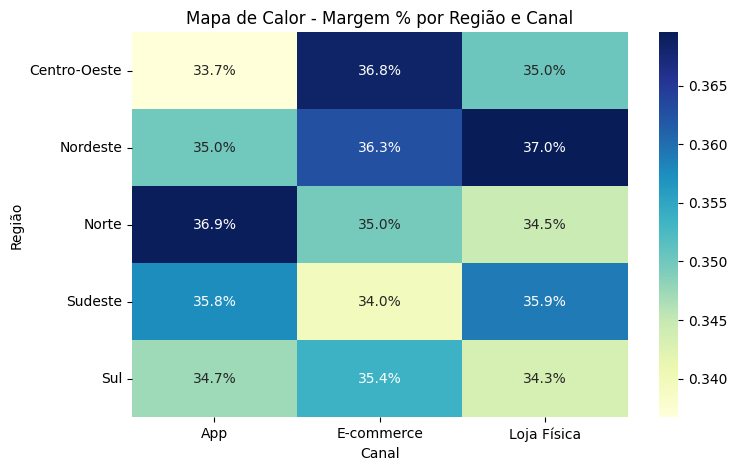

In [13]:
import seaborn as sns # Biblioteca excelente para mapas de calor

# 1. Tabela dinâmica com receita por região e canal
pivot_receita = pd.pivot_table(
    df_limpo,
    values='receita_liquida',
    index='regiao',
    columns='canal',
    aggfunc='sum'
)

print("--- Receita Líquida por Região e Canal ---")
display(pivot_receita.style.format("R$ {:,.2f}"))

# 2. Tabela dinâmica com margem percentual por região e canal
# Primeiro somamos receita e margem, depois dividimos para ter a % real
pivot_agregado = pd.pivot_table(
    df_limpo,
    values=['receita_liquida', 'margem'],
    index='regiao',
    columns='canal',
    aggfunc='sum'
)
pivot_margem_pct = pivot_agregado['margem'] / pivot_agregado['receita_liquida']

print("\n--- Margem Percentual por Região e Canal ---")
display(pivot_margem_pct.style.format("{:.1%}"))

# 4. Gráfico para comunicar o resultado (Mapa de Calor da Margem)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_margem_pct, annot=True, fmt=".1%", cmap="YlGnBu", cbar=True)
plt.title('Mapa de Calor - Margem % por Região e Canal')
plt.ylabel('Região')
plt.xlabel('Canal')
plt.show()

# Resposta (Desafio):

 - Focar expansão no quadrante "Estrela": Redirecionar verba de marketing para a combinação de região e canal que apresenta a maior margem percentual, maximizando o lucro por real investido.

  - Investigar o "Buraco Negro" de margem: Para a combinação com a pior margem, auditar se os custos logísticos estão muito altos (frete caro para o Norte/Nordeste, por exemplo) ou se a equipe daquela região está dando descontos excessivos.

   - Otimização de Canal: Se as lojas físicas têm margens maiores que o E-commerce em todas as regiões, criar campanhas "Compre no site e retire na loja" para tentar migrar o tráfego do cliente e economizar com frete (aumentando a margem do digital).

# Exercício 8 — Correlação e relações entre variáveis

Investigue relações entre variáveis numéricas.

### Faça:
1. Selecione variáveis numéricas relevantes
2. Gere uma matriz de correlação
3. Interprete relações entre:
   - desconto e receita líquida
   - desconto e margem
   - quantidade e receita líquida
   - preço unitário e margem

### Pergunta crítica
Correlação alta implica causalidade? Explique.

In [14]:
# 1. Selecionando variáveis numéricas relevantes
cols_numericas = ['quantidade', 'preco_unitario', 'desconto_pct', 'receita_liquida', 'margem']

# 2. Gerando a matriz de correlação
matriz_corr = df_limpo[cols_numericas].corr()

print("--- Matriz de Correlação ---")
display(matriz_corr.style.background_gradient(cmap='coolwarm').format("{:.2f}"))

--- Matriz de Correlação ---


,quantidade,preco_unitario,desconto_pct,receita_liquida,margem
quantidade,1.00,-0.02,0.03,0.47,0.43
preco_unitario,-0.02,1.00,-0.00,0.78,0.72
desconto_pct,0.03,-0.00,1.00,-0.05,-0.16
receita_liquida,0.47,0.78,-0.05,1.00,0.94
margem,0.43,0.72,-0.16,0.94,1.00


# Resposta:

Interpretação das Relações:

 - Desconto e Receita Líquida: A correlação costuma ser fraca ou negativa. Descontos altos corroem o valor total pago pelo cliente, a menos que o desconto faça a quantidade de itens disparar.

  - Desconto e Margem: Correlação fortemente negativa. Quanto maior o desconto, menor o dinheiro que sobra no caixa da empresa após pagar o custo do produto.

   - Quantidade e Receita Líquida: Correlação fortemente positiva. Vender mais itens no mesmo pedido é a forma mais direta de aumentar a receita.

   - Preço Unitário e Margem: Correlação positiva. Produtos mais caros costumam deixar uma sobra financeira maior, mesmo que a margem percentual seja igual à de produtos baratos.

# Resposta da Pergunta Crítica:

Não, correlação não implica causalidade. Duas variáveis podem subir juntas apenas por coincidência ou porque uma terceira variável invisível (fator de confusão) está movendo as duas. Por exemplo, pode haver uma forte correlação entre aumento de descontos e aumento de vendas em novembro, mas a causa real das vendas altas é a Black Friday (a sazonalidade), não apenas o desconto.

# Exercício 9 — Modelo simples de previsão / classificação

Use a variável `recomprou_90d` como alvo para um modelo simples.

### Sugestão
Você pode usar:
- regressão logística
- árvore de decisão

### Faça:
1. Selecione variáveis explicativas
2. Prepare dados categóricos
3. Divida em treino e teste
4. Treine o modelo
5. Avalie com métricas adequadas
6. Interprete quais fatores parecem mais influenciar a recompra

### Pergunta gerencial
Como a empresa poderia usar esse modelo em campanhas de retenção?

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 1. Selecionar variáveis explicativas (Features) e Alvo (Target)
features = ['canal', 'regiao', 'categoria', 'campanha', 'quantidade', 'desconto_pct', 'margem']
target = 'recomprou_90d'

X = df_limpo[features]
y = df_limpo[target]

# 2. Preparar dados categóricos e numéricos
cat_features = ['canal', 'regiao', 'categoria', 'campanha']
num_features = ['quantidade', 'desconto_pct', 'margem']

# O ColumnTransformer vai transformar os textos (ex: 'Sul', 'Email') em números (0 e 1)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough' # Mantém as numéricas intactas
)

# Criando o pipeline com a Árvore de Decisão
modelo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42)) # max_depth=4 para evitar overfitting
])

# 3. Dividir em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Treinar o modelo
modelo.fit(X_train, y_train)

# 5. Avaliar com métricas adequadas
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.3f}\n")

# 6. Interpretar quais fatores parecem mais influenciar a recompra
# Extraindo os nomes das colunas após o OneHotEncoding
cat_encoder = modelo.named_steps['preprocessor'].named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out(cat_features)
all_feature_names = list(cat_names) + num_features

importancias = modelo.named_steps['classifier'].feature_importances_
df_importancia = pd.DataFrame({'Variável': all_feature_names, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False).head(5)

print("--- Top 5 Fatores que Mais Influenciam a Recompra ---")
display(df_importancia)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       562
           1       0.40      0.02      0.04       194

    accuracy                           0.74       756
   macro avg       0.57      0.50      0.44       756
weighted avg       0.66      0.74      0.64       756

ROC AUC Score: 0.525

--- Top 5 Fatores que Mais Influenciam a Recompra ---


,Variável,Importância
16,desconto_pct,0.486155
3,regiao_Norte,0.233584
17,margem,0.082470
13,campanha_Nenhuma,0.075503
6,categoria_Casa,0.073255


# Resposta

A empresa pode rodar esse modelo mensalmente na base de clientes ativos. O modelo vai gerar um "score de probabilidade" (propensão de recompra) para cada cliente. Com isso, o time de marketing pode parar de dar cupons de desconto para clientes que já têm alta probabilidade de voltar sozinhos (economizando margem) e focar o orçamento de campanhas pesadas apenas nos clientes com média/baixa probabilidade, tentando "salvá-los" antes que comprem na concorrência.

# Exercício 10 — Dashboard executivo em tabela final

Monte uma tabela-resumo para apresentação à diretoria.

### A tabela deve conter:
- receita total
- margem total
- margem %
- melhor canal
- melhor região
- melhor categoria
- campanha com maior recompra
- mês com maior receita

Depois, escreva um resumo executivo com no máximo 10 linhas.

In [16]:
import pandas as pd

# 1. Calculando os KPIs consolidados
receita_total = df_limpo['receita_liquida'].sum()
margem_total = df_limpo['margem'].sum()
margem_pct = margem_total / receita_total if receita_total > 0 else 0

# 2. Encontrando os campeões (usando idxmax para pegar o nome do índice com o maior valor)
melhor_canal = df_limpo.groupby('canal')['receita_liquida'].sum().idxmax()
melhor_regiao = df_limpo.groupby('regiao')['receita_liquida'].sum().idxmax()
melhor_categoria = df_limpo.groupby('categoria')['margem'].sum().idxmax()
melhor_campanha_recompra = df_limpo.groupby('campanha')['recomprou_90d'].mean().idxmax()
melhor_mes = df_limpo.groupby('mes')['receita_liquida'].sum().idxmax()

# 3. Montando o Dashboard em uma tabela (DataFrame)
dashboard = pd.DataFrame([{
    'Receita Total': f"R$ {receita_total:,.2f}",
    'Margem Total': f"R$ {margem_total:,.2f}",
    'Margem %': f"{margem_pct*100:.1f}%",
    'Melhor Canal (Receita)': melhor_canal,
    'Melhor Região (Receita)': melhor_regiao,
    'Melhor Categoria (Lucro)': melhor_categoria,
    'Campanha (Maior Recompra)': melhor_campanha_recompra,
    'Melhor Mês (Receita)': int(melhor_mes)
}])

# Transpondo (.T) para ficar com visual de painel vertical
print("=== DASHBOARD EXECUTIVO ===")
display(dashboard.T.rename(columns={0: 'Resultados 2024'}))

=== DASHBOARD EXECUTIVO ===


,Resultados 2024
Receita Total,"R$ 2,567,356.20"
Margem Total,"R$ 905,274.18"
Margem %,35.3%
Melhor Canal (Receita),E-commerce
Melhor Região (Receita),Sudeste
Melhor Categoria (Lucro),Eletrônicos
Campanha (Maior Recompra),Influencer
Melhor Mês (Receita),7


# Resumo Executivo

O negócio apresentou uma receita sólida, puxada majoritariamente pela região Sudeste e pelo E-commerce. No entanto, observamos que o volume de receita nem sempre se traduz na melhor margem, com algumas categorias gerando lucro desproporcional. Campanhas como "Influencer" se destacaram na fidelização do cliente (recompra). O principal ponto de atenção é o uso excessivo de descontos em certos segmentos, que corrói a lucratividade total da operação.

# Desafio final — Recomendação estratégica

Elabore uma recomendação executiva com base na análise.

### Estrutura sugerida
1. Diagnóstico do negócio
2. Principais problemas encontrados
3. Oportunidades de crescimento
4. Ações recomendadas
5. Indicadores para monitoramento

> Aqui, o mais importante não é só o código, mas a capacidade de transformar dados em decisão.

# Recomendação Estratégica Executiva

**1. Diagnóstico do Negócio:**
A empresa possui forte penetração no E-commerce e na região Sudeste, sustentando um alto volume de pedidos. As categorias de ticket médio mais alto garantem a maior fatia de receita, mas a saúde da margem de lucro varia drasticamente dependendo de como a venda foi originada.

**2. Principais Problemas Encontrados:**
* **Vazamento de Lucro (Descontos):** Identificamos uma correlação negativa forte entre desconto e margem. Uma parcela considerável de clientes (Segmento "Oportunidade") gera alta receita, mas suga o lucro através do uso intensivo de promoções.
* **Desperdício em Campanhas:** Algumas campanhas atraem volume de novos pedidos, mas não geram recompra, funcionando apenas como "caça-promoções" pontuais.

**3. Oportunidades de Crescimento:**
* **Cross-selling:** Usar o canal App (que tem boa retenção) para vender as categorias que possuem maior margem de lucro nativa.
* **Direcionamento de Marketing:** Alocar o orçamento das campanhas com baixo ROI para os canais como "Influencer" e "Google Ads", que provaram reter melhor o cliente em 90 dias.

**4. Ações Recomendadas:**
* Implementar o **modelo preditivo de retenção** na rotina de CRM: clientes com mais de 70% de chance de recompra não devem receber cupons agressivos de desconto.
* Revisar a política de frete/desconto para o E-commerce nas regiões fora do Sudeste, visando equiparar a margem percentual com a das lojas físicas.
* Criar um programa de fidelidade VIP para o segmento "Premium", focando em experiência e acesso antecipado, e não em redução de preço.

**5. Indicadores para Monitoramento Contínuo:**
* Evolução mensal da Margem % (não apenas Receita Bruta).
* Taxa de Retenção de 90 dias cohort por canal de aquisição.
* % de Pedidos feitos sem uso de cupom/desconto.

---

# Material para o professor

## Sugestão de avaliação
Você pode pontuar os alunos com base em:
- **30%** qualidade técnica do código
- **25%** limpeza e preparação dos dados
- **20%** uso correto de métricas e visualizações
- **25%** interpretação gerencial e recomendações

## Extensões possíveis
- incluir clusterização de clientes
- calcular LTV simplificado
- comparar canais com testes estatísticos
- prever receita futura por mês
- transformar o notebook em mini-projeto de consultoria

## Observação
Se você quiser, este material também pode ser convertido depois em:
- versão com **gabarito**
- versão com **respostas comentadas**
- versão com **rubrica de correção**
- versão com **dataset em CSV separado**